In [166]:
import sys,os
sys.path.append("../../src")
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from quspin_functions import projector_string as Pn
from quspin_functions import TFIM 
from project_imports import *
import numpy.linalg as la
from numpy import vdot 

In [167]:
def NonIntegrableTFIM(basis):
    L = basis.L
    NN = [[-1,i,(i+1)%L] for i in range(L)]
    NNN = [[0.2,i,(i+2)%L] for i in range(L)]
    single_site = [ [-1, i] for i in range(L)]

    ferro_terms = [["xx",NN],["xx",NNN]]
    para_terms = [["z",single_site]]
    op_dict = dict(H0=ferro_terms,g=para_terms)

    return quantum_operator(op_dict,basis=basis,check_herm=False,check_symm=False)

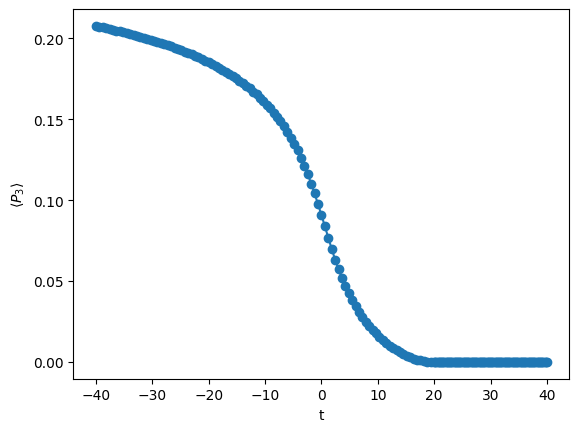

In [74]:
# expectation value <P3>(t)
P3_t = np.array([vdot(psi_t[:,i], P.dot(psi_t[:,i])) for i in range(len(times))]).real


plt.figure()
plt.plot(times, 1/2-P3_t, "o-")
plt.xlabel("t")
plt.ylabel(r"$\langle P_3 \rangle$")
plt.show()

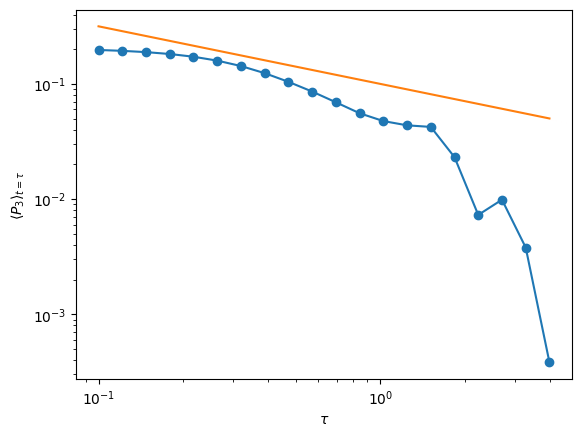

In [9]:
taus = np.logspace(-1, .6, 20)
P3_final = []

for tau in taus:

    # evolve times
    times = np.linspace(-tau*(g0-1), tau, N_timestep)

    psi_t = evolve(
        psi0,
        times[0],
        times,
        schrodinger_rhs,
        f_params=(H0_mat, Quench_mat, tau),
        iterate=False
    )

    psi_f = psi_t[:, -1]  # state at end of quench

    P3_final.append(np.real(vdot(psi_f, P.dot(psi_f))))

P3_final = np.array(P3_final)

import matplotlib.pyplot as plt
plt.figure()
plt.plot(taus, 1/2-P3_final, "o-")
plot(taus,taus**(-1/2)/10)
plt.loglog()
plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle P_3 \rangle_{t=\tau}$")
plt.show()

In [ ]:
L = 10
g0 =1.5
gf=0
tau = 20
N_timestep = 400
basis = spin_basis_1d(L,pauli=-1,pblock=1)
#H = NonIntegrableTFIM(basis)
H = TFIM(basis)
params = dict(H0=1,g=0)
H0 = (H.tohamiltonian(params).todense())
E0,V0 = la.eigh(H0)
psi0 = V0[:,0]

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/scipy/integrate/_ode.py:438: UserWarning: dop853: input is not consistent
  self._y, self.t = mth(self.f, self.jac or (lambda: None),


RuntimeError: failed to evolve to time -9.924812030075188, nsteps might be too small

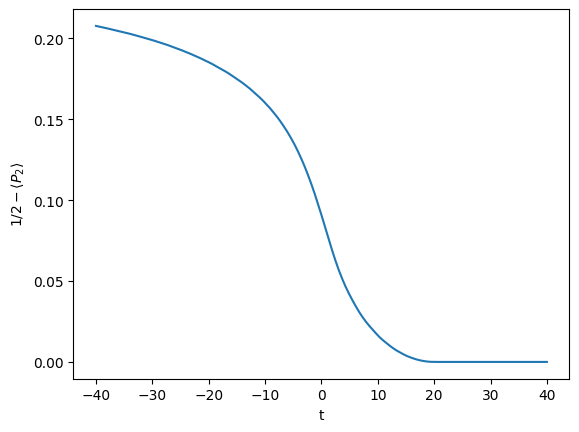

In [ ]:
L = 10
g0 = 3
gf = 0
tau = 20
N_timestep = 100

basis = spin_basis_1d(L, pauli=-1)
H = TFIM(basis)
#H = NonIntegrableTFIM(basis)

P = Pn(2, "x", basis)

H0_mat     = H.tohamiltonian(dict(H0=1, g=0)).tocsr()
Quench_mat = H.tohamiltonian(dict(H0=0, g=1)).tocsr()

# initial state (ground state at g=g0)
H_init = (H0_mat + g0*Quench_mat).toarray()
E0, V0 = la.eigh(H_init)
psi0 = V0[:,0]

# time-dependent RHS during quench
def schrodinger_rhs(t, psi, H0_mat, Quench_mat, tau, gf):
    g = 1 - t/tau
    if g < gf:
        g = gf
    return -1j * (H0_mat + g*Quench_mat).dot(psi)

# time where quench stops
t_stop = tau*(1-gf)

# time grids
times_quench = np.linspace(-tau*(g0-1), t_stop, N_timestep)
times_free   = np.linspace(t_stop, t_stop + 20, N_timestep)

# evolve quench
psi_quench = evolve(
    psi0,
    times_quench[0],
    times_quench,
    schrodinger_rhs,
    f_params=(H0_mat, Quench_mat, tau, gf),
    iterate=False
)

psi_mid = psi_quench[:, -1]

# fixed Hamiltonian for free evolution
H_free = H0_mat + gf*Quench_mat

def free_rhs(t, psi, H_free):
    return -1j * H_free.dot(psi)

# free evolution
psi_free = evolve(
    psi_mid,
    times_free[0],
    times_free,
    free_rhs,
    f_params=(H_free,),
    iterate=False
)

# combine trajectories
psi_t = np.concatenate((psi_quench, psi_free[:,1:]), axis=1)
times = np.concatenate((times_quench, times_free[1:]))

# expectation value <P2>(t)
P_t = np.array([vdot(psi_t[:,i], P.dot(psi_t[:,i])) for i in range(len(times))]).real

plt.figure()
plot(times, 0.5 - P_t)
xlabel("t")
ylabel(r"$1/2-\langle P_2 \rangle$")
show()

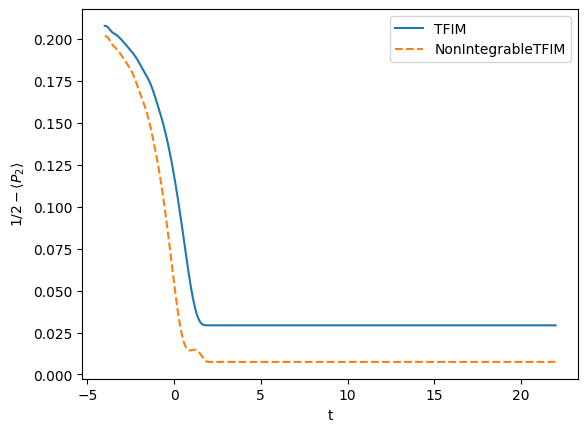

In [45]:
L = 10
g0 = 3
gf = 0
tau = 2
N_timestep = 100

basis = spin_basis_1d(L, pauli=-1)

# build both Hamiltonians
H_int  = TFIM(basis)
H_non  = NonIntegrableTFIM(basis)

P = Pn(2, "x", basis)

def run_quench(H):

    H0_mat     = H.tohamiltonian(dict(H0=1, g=0)).tocsr()
    Quench_mat = H.tohamiltonian(dict(H0=0, g=1)).tocsr()

    H_init = (H0_mat + g0*Quench_mat).toarray()
    E0, V0 = la.eigh(H_init)
    psi0 = V0[:,0]

    def schrodinger_rhs(t, psi, H0_mat, Quench_mat, tau, gf):
        g = 1 - t/tau
        if g < gf:
            g = gf
        return -1j * (H0_mat + g*Quench_mat).dot(psi)

    t_stop = tau*(1-gf)

    times_quench = np.linspace(-tau*(g0-1), t_stop, N_timestep)
    times_free   = np.linspace(t_stop, t_stop + 20, N_timestep)

    psi_quench = evolve(
        psi0,
        times_quench[0],
        times_quench,
        schrodinger_rhs,
        f_params=(H0_mat, Quench_mat, tau, gf),
        iterate=False
    )

    psi_mid = psi_quench[:, -1]

    H_free = H0_mat + gf*Quench_mat

    def free_rhs(t, psi, H_free):
        return -1j * H_free.dot(psi)

    psi_free = evolve(
        psi_mid,
        times_free[0],
        times_free,
        free_rhs,
        f_params=(H_free,),
        iterate=False
    )

    psi_t = np.concatenate((psi_quench, psi_free[:,1:]), axis=1)
    times = np.concatenate((times_quench, times_free[1:]))

    P_t = np.array([vdot(psi_t[:,i], P.dot(psi_t[:,i])) for i in range(len(times))]).real

    return times, P_t


times_int, P_int = run_quench(H_int)
times_non, P_non = run_quench(H_non)

plt.figure()
plot(times_int, 0.5 - P_int, label="TFIM")
plot(times_non, 0.5 - P_non, "--", label="NonIntegrableTFIM")
xlabel("t")
ylabel(r"$1/2-\langle P_2 \rangle$")
legend()
show()

In [84]:
L = 10
g0 = 2
gf = 0
taus = np.logspace(-3,1,5)
N_timestep = 100

basis = spin_basis_1d(L, pauli=-1)

H_int = TFIM(basis)
H_non = NonIntegrableTFIM(basis)

ns = np.arange(1,7)

def run_quench_avg(H,n,tau):


    H0_mat     = H.tohamiltonian(dict(H0=1, g=0)).tocsr()
    Quench_mat = H.tohamiltonian(dict(H0=0, g=1)).tocsr()

    H_init = (H0_mat + g0*Quench_mat).toarray()
    E0,V0 = la.eigh(H_init)
    psi0 = V0[:,0]

    def schrodinger_rhs(t,psi,H0_mat,Quench_mat,tau,gf):
        g = 1 - t/tau
        if g < gf:
            g = gf
        return -1j*(H0_mat + g*Quench_mat).dot(psi)

    t_stop = tau*(1-gf)

    times_quench = np.linspace(-tau*(g0-1),t_stop,N_timestep)
    times_free   = np.linspace(t_stop,t_stop+20,N_timestep)

    psi_quench = evolve(
        psi0,
        times_quench[0],
        times_quench,
        schrodinger_rhs,
        f_params=(H0_mat,Quench_mat,tau,gf),
        iterate=False
    )

    psi_mid = psi_quench[:,-1]

    H_free = H0_mat + gf*Quench_mat

    def free_rhs(t,psi,H_free):
        return -1j*H_free.dot(psi)

    psi_free = evolve(
        psi_mid,
        times_free[0],
        times_free,
        free_rhs,
        f_params=(H_free,),
        iterate=False
    )

    vals = np.array([vdot(psi_free[:,i],P.dot(psi_free[:,i])) for i in range(psi_free.shape[1])]).real
    return np.mean(vals)



In [79]:
# ---- collect data first ----
data_int = []
data_non = []

for tau in taus:

    vals_int = []
    vals_non = []

    for n in ns:
        vals_int.append(run_quench_avg(H_int, n, tau))
        vals_non.append(run_quench_avg(H_non, n, tau))

    vals_int = -np.log(np.array(vals_int))
    vals_non = -np.log(np.array(vals_non))

    data_int.append(vals_int)
    data_non.append(vals_non)

data_int = np.array(data_int)
data_non = np.array(data_non)




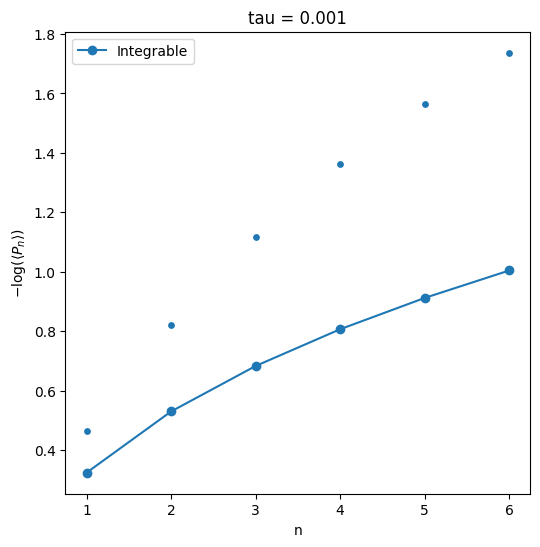

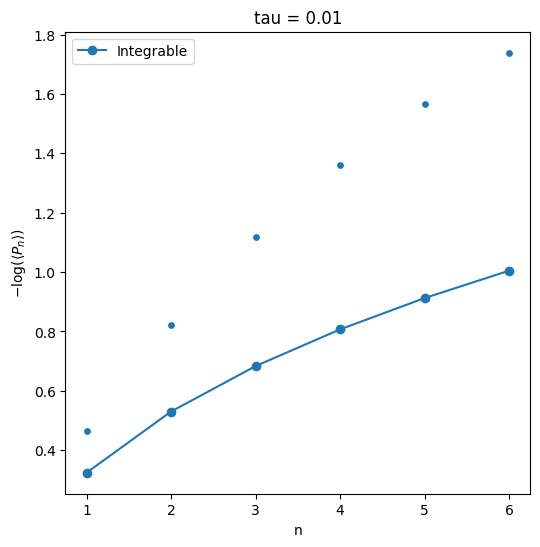

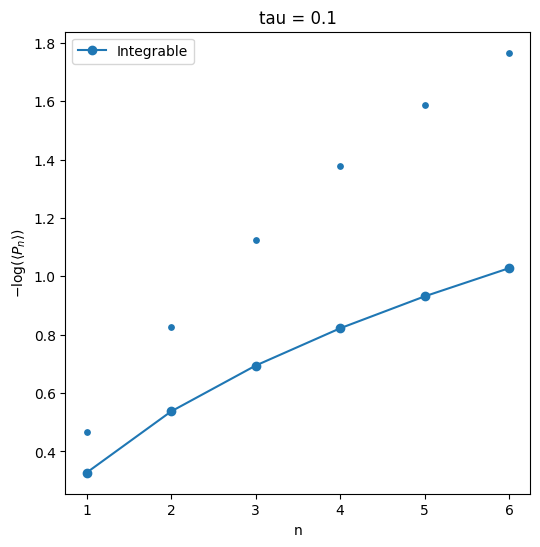

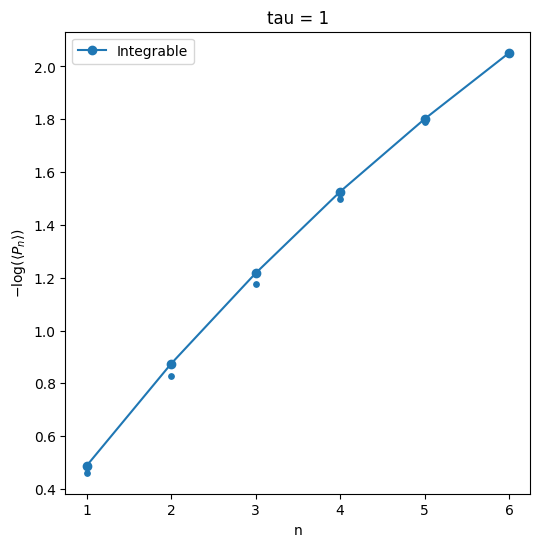

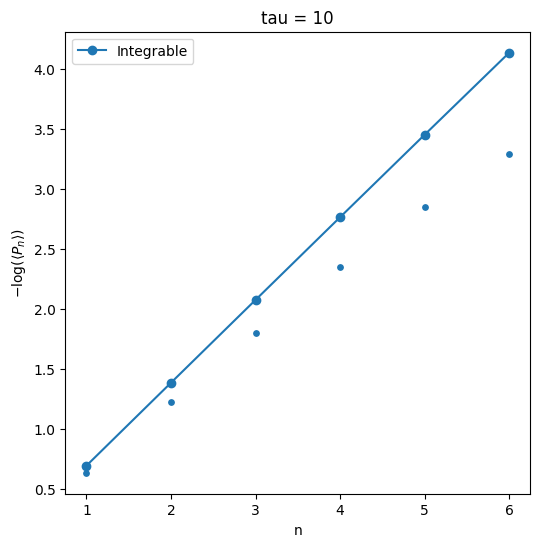

In [80]:
# ---- plotting ----
for i, tau in enumerate(taus):

    plt.figure(figsize=(6,6))
    plt.plot(ns, data_int[i], "o-", label="Integrable")
    plt.scatter(ns, data_non[i], s=15)

    plt.xlabel("n")
    plt.ylabel(r"$-\log(\langle P_n \rangle)$")
    plt.title(f"tau = {tau:.3g}")
    plt.legend()
    plt.show()

In [86]:
taus = [0.001,.01,.1,1,1.5,3,6,12,24]

In [87]:
# ---- compute Px and Pz data vs tau ----

data_int_z = []
data_int_x = []
data_non_z = []
data_non_x = []

for tau in taus:

    vals_int_z = []
    vals_int_x = []
    vals_non_z = []
    vals_non_x = []

    for n in ns:
        P = Pn(n,"z",basis)

        vals_int_z.append(run_quench_avg(H_int, n, tau))
        vals_non_z.append(run_quench_avg(H_non, n, tau))

        P = Pn(n,"x",basis)

        vals_int_x.append(run_quench_avg(H_int, n, tau))
        vals_non_x.append(run_quench_avg(H_non, n, tau))

    data_int_z.append(vals_int_z)
    data_non_z.append(vals_non_z)
    data_int_x.append(vals_int_x)
    data_non_x.append(vals_non_x)

data_int_z = np.array(data_int_z)
data_non_z = np.array(data_non_z)
data_int_x = np.array(data_int_x)
data_non_x = np.array(data_non_x)




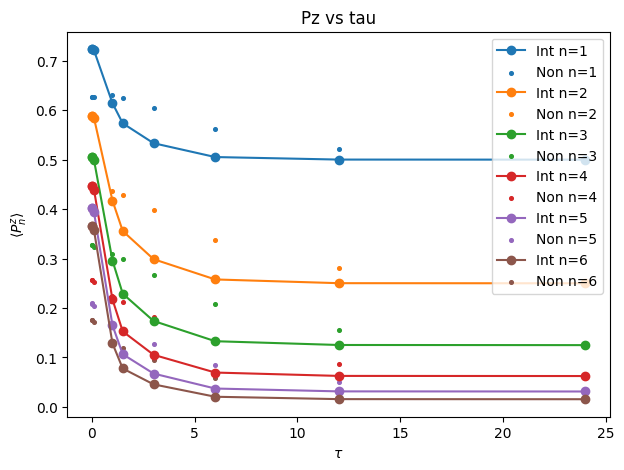

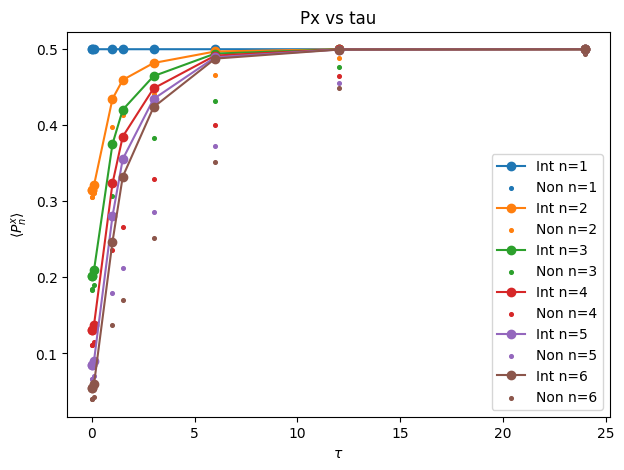

In [88]:
# ---- plot Pz vs tau ----
plt.figure(figsize=(7,5))

for i,n in enumerate(ns):
    plt.plot(taus, data_int_z[:,i], "o-", label=f"Int n={n}")
    plt.scatter(taus, data_non_z[:,i], s=7, label=f"Non n={n}")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle P_n^z \rangle$")
plt.legend()
plt.title("Pz vs tau")
plt.show()


# ---- plot Px vs tau ----
plt.figure(figsize=(7,5))

for i,n in enumerate(ns):
    plt.plot(taus, data_int_x[:,i], "o-", label=f"Int n={n}")
    plt.scatter(taus, data_non_x[:,i], s=7, label=f"Non n={n}")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle P_n^x \rangle$")
plt.legend()
plt.title("Px vs tau")
plt.show()

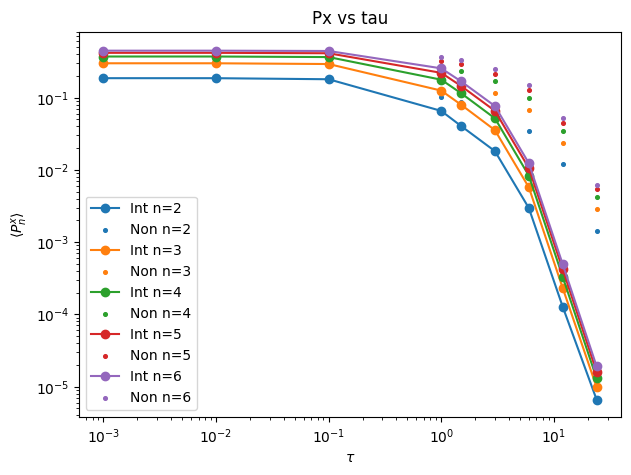

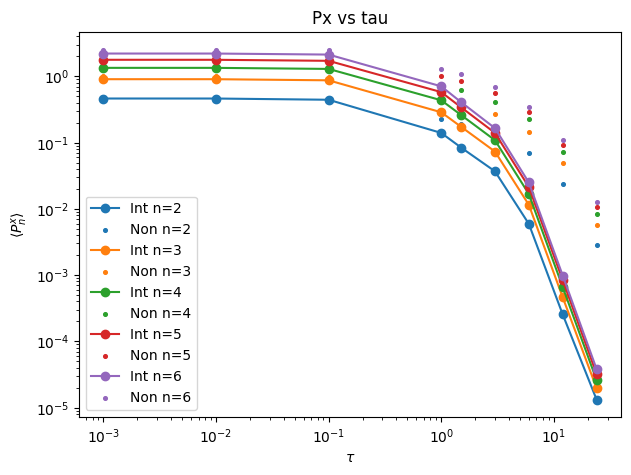

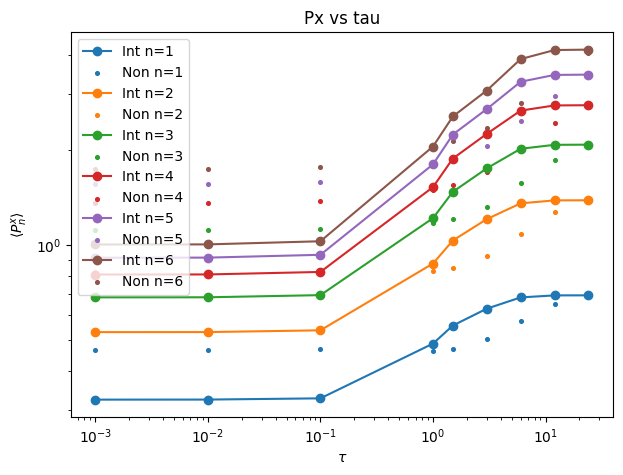

In [97]:

# ---- plot Px vs tau ----
plt.figure(figsize=(7,5))

for i,n in enumerate(ns):
    if n==1:
        pass
    else:
        plt.plot(taus, 1/2-data_int_x[:,i], "o-", label=f"Int n={n}")
        plt.scatter(taus, 1/2-data_non_x[:,i], s=7, label=f"Non n={n}")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle P_n^x \rangle$")
plt.legend()
plt.title("Px vs tau")
loglog()
plt.show()

# ---- plot Px vs tau ----
plt.figure(figsize=(7,5))

for i,n in enumerate(ns):
    if n ==1: 
        pass
    else:
       plt.plot(taus, -np.log(2*data_int_x[:,i]), "o-", label=f"Int n={n}")
       plt.scatter(taus, -np.log(2*data_non_x[:,i]), s=7, label=f"Non n={n}")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle P_n^x \rangle$")
plt.legend()
plt.title("Px vs tau")
loglog()
plt.show()

# ---- plot Px vs tau ----
plt.figure(figsize=(7,5))

for i,n in enumerate(ns):
    if n ==1000: 
        pass
    else:
       plt.plot(taus, -np.log(data_int_z[:,i]), "o-", label=f"Int n={n}")
       plt.scatter(taus, -np.log(data_non_z[:,i]), s=7, label=f"Non n={n}")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle P_n^x \rangle$")
plt.legend()
plt.title("Px vs tau")
loglog()
plt.show()

In [160]:
L = 10
g0 =0
gf=0
tau = 20
N_timestep = 400
basis = spin_basis_1d(L,pauli=-1,pblock=1)
#H = NonIntegrableTFIM(basis)
H = TFIM(basis)
params = dict(H0=1,g=g0)
H0 = (H.tohamiltonian(params).todense())
E0,V0 = la.eigh(H0)
psi0 = V0[:,0]

P=Pn(2,"x",basis)

X = P@psi0

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/974579890.py:16: RuntimeWarning: divide by zero encountered in matmul
  X = P@psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/974579890.py:16: RuntimeWarning: overflow encountered in matmul
  X = P@psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/974579890.py:16: RuntimeWarning: invalid value encountered in matmul
  X = P@psi0


In [161]:
X = P @ psi0
X = X / np.linalg.norm(X)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/3862103895.py:1: RuntimeWarning: divide by zero encountered in matmul
  X = P @ psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/3862103895.py:1: RuntimeWarning: overflow encountered in matmul
  X = P @ psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/3862103895.py:1: RuntimeWarning: invalid value encountered in matmul
  X = P @ psi0


In [162]:
import numpy as np
from quspin.operators import hamiltonian
def nk_operator(k,L,basis):
    terms = []
    for j in range(L):
        for l in range(L):
            coef = np.exp(1j*k*(j-l))/L
            terms.append([coef,j,l])
    return hamiltonian([["+-",terms]],[],basis=basis,dtype=np.complex128,check_symm=False).toarray()

In [163]:
k = 2*np.pi*1/L     # choose momentum index
X = P @ psi0
X = X/np.linalg.norm(X)

Nk = nk_operator(k,L,basis)
val = np.vdot(X, Nk @ X)

Hermiticity check passed!


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/28099421.py:2: RuntimeWarning: divide by zero encountered in matmul
  X = P @ psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/28099421.py:2: RuntimeWarning: overflow encountered in matmul
  X = P @ psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/28099421.py:2: RuntimeWarning: invalid value encountered in matmul
  X = P @ psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/28099421.py:6: RuntimeWarning: divide by zero encountered in matmul
  val = np.vdot(X, Nk @ X)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/28099421.py:6: RuntimeWarning: overflow encountered in matmul
  val = np.vdot(X, Nk @ X)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/28099421.py:6: RuntimeWarning: invalid value encountered in matmul
  val = np.vdot(X, Nk @ X)


In [164]:
def bogoliubov_uv(k,g):
    eps = 2*np.sqrt((g-np.cos(k))**2 + np.sin(k)**2)
    u = np.sqrt(0.5*(1+(g-np.cos(k))/eps))
    v = 1j*np.sin(k)/np.sqrt(2*eps*(eps+g-np.cos(k)))
    return u,v

def ck_terms(k,L):
    terms = []
    for j in range(L):
        for l in range(L):
            coef = np.exp(1j*k*(j-l))/L
            terms.append([coef,j,l])
    return terms

def nk_operator(k,g,L,basis):
    u,v = bogoliubov_uv(k,g)

    terms = []

    # c_k† c_k
    for coef,j,l in ck_terms(k,L):
        terms.append([coef*abs(u)**2,j,l])

    # c_-k c_-k†
    for coef,j,l in ck_terms(-k,L):
        terms.append([coef*abs(v)**2,l,j])

    static = [["+-",terms]]
    return hamiltonian(static,[],basis=basis,dtype=np.complex128,check_symm=False).toarray()

Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/3102793785.py:5: RuntimeWarning: divide by zero encountered in matmul
  X = P @ psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/3102793785.py:5: RuntimeWarning: overflow encountered in matmul
  X = P @ psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/3102793785.py:5: RuntimeWarning: invalid value encountered in matmul
  X = P @ psi0
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/3102793785.py:14: RuntimeWarning: divide by zero encountered in matmul
  val = np.vdot(X, Nk @ X).item()   # convert to scalar
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/3102793785.py:14: RuntimeWarning: overflow encountered in matmul
  val = np.vdot(X, Nk @ X).item()   # convert to scalar
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32369/3102793785.py:14: RuntimeWarning: invalid value encountered in matmul
  val = np.vdot(X, Nk @ X).item()   # conver

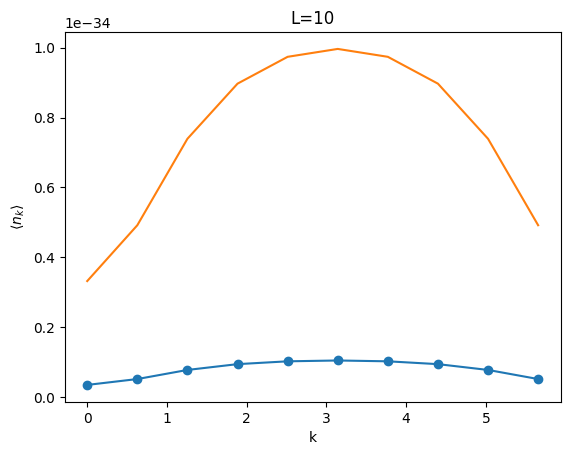

In [165]:
import numpy as np
import matplotlib.pyplot as plt

# projected state
X = P @ psi0
X = X/np.linalg.norm(X)

ks = []
vals = []
vals2= []
for m in range(L):
    k = 2*np.pi*m/L
    Nk = nk_operator(k,gf,L,basis)
    val = np.vdot(X, Nk @ X).item()   # convert to scalar
    vals2.append(np.vdot(psi0,Nk@psi0).item())
    ks.append(k)
    vals.append(np.real(val))

ks = np.array(ks)
vals = np.array(vals)

plt.plot(ks,vals,"o-")
plot(ks,vals2)
plt.xlabel("k")
plt.ylabel(r"$\langle n_k \rangle$")
plt.title(f"L={L}")
plt.show()